# Hybrid ALNS Performance Evaluation

## I. Purpose

This notebook benchmarks the **Hybrid Adaptive Large Neighbourhood Search (ALNS)** solver on the classic 1-D Bin Packing Problem.

The solver combines three ideas:

| Component | Role |
|---|---|
| **Adaptive Large Neighbourhood Search** | Iteratively destroys and repairs a solution to escape local optima |
| **Thompson Sampling bandit** | Adaptively selects among three destroy operators (random, worst-bin, related-items) based on their historical success rates |
| **Offline learned repair model** | A pre-trained classifier (`repair_model_v2.pkl`) replaces the greedy insertion heuristic, scoring each candidate bin and placing each displaced item into the bin with the highest predicted quality |

After each repair pass a **consolidation** local search merges under-loaded bins, further reducing the bin count.

### What this notebook does

1. Loads the trained repair model.
2. Runs the full benchmark suite against the **Falkenauer-T** (triplet) dataset.
3. Computes summary statistics (completion rate, average gap to lower bound, solve times).
4. Renders diagnostic charts inline.

## II. Imports and Reproducibility Controls

### Required artefacts

Before running this notebook, make sure the following are present:

- **Repair model** — `bin_packing_optimization/hybrid_learning_metaheuristics/hybrid_alns/models/repair_model_v2.pkl`  
  This bundle contains the trained classifier, a fitted feature scaler, the feature version tag, and the expected feature count. The solver will reject a bundle with a mismatched version or feature count so that stale models are never silently used.

- **Dataset directory** — `datasets/` at the repository root.  
  Instance files are discovered automatically by the `Benchmark` class via the dataset registry.

### Reproducibility

- The `BinPackingSolver` defaults to `seed=42`; all ALNS stochastic decisions (destroy operator sampling, Simulated Annealing acceptance) flow through a single `numpy.random.Generator` seeded from this value.
- The iteration budget is fixed at **2 000 iterations** per instance. No wall-clock time limit is imposed, so every instance runs to completion.
- The `Benchmark` runner sorts instances by `(num_items, name)` before execution, so the order is deterministic across runs.

In [1]:
from bin_packing_optimization.hybrid_learning_metaheuristics.hybrid_alns import hybrid_alns_solver
from bin_packing_optimization.hybrid_learning_metaheuristics.hybrid_alns.models import load_repair_model
from bin_packing_optimization.utilities.benchmarking import Benchmark, create_benchmark
from bin_packing_optimization.utilities.graphing import display_graphs
from bin_packing_optimization.utilities.statistics import print_benchmark_report


## III. Hybrid Run (ALNS + Offline Repair Model)

### 1 — Load the repair model

`load_repair_model` deserialises the `.pkl` bundle and validates it against the solver's current feature schema:

- **`feature_version`** — must match the compile-time constant in `features.py`; guards against using a model trained on a different feature set.
- **`n_features`** — the expected column count of the feature matrix; a mismatch would cause silent dimension errors at inference time.
- **`scaler`** — a fitted `StandardScaler` (or `None`); if present it is applied to every feature matrix before the model scores candidate bins.

A `TypeError` or `ValueError` here means the model file needs to be regenerated with `train_repair_model.py`.

In [2]:
model_bundle = load_repair_model("repair_model_v2.pkl")

/home/amine/Documents/Projects/bin-packing-optimization/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DummyClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/amine/Documents/Projects/bin-packing-optimization/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/amine/Documents/Projects/bin-packing-optimization/.venv/lib/python3.12/site-packages/sklearn/base.

### 2 — Create and run the benchmark

`create_benchmark` resolves the dataset key `"falkenauer-t"` through the dataset registry to obtain the matching `DatasetConfig` (directory path, file parser, and human-readable label), then wraps it in a `Benchmark` object.

`benchmark.run()` iterates over every instance file in sorted order. For each instance it:
1. Builds a `BinPackingSolver` with the instance's item sizes and bin capacity.
2. Calls `solver.solve(max_iterations=2000, model_bundle=model_bundle)`, which:
   - Constructs a First-Fit Decreasing (FFD) starting solution.
   - Runs 2 000 ALNS iterations with Thompson-Sampling operator selection and Simulated Annealing acceptance.
   - Applies the learned repair model at each reconstruction step and a consolidation pass afterwards.
3. Records `bins_used`, `elapsed_time`, the continuous lower bound `⌈total_weight / capacity⌉`, and whether the run timed out.

Because no `time_limit` was set on the `Benchmark`, every instance runs in the calling process — no subprocess overhead, no risk of time-out.

Results are written to a timestamped CSV file whose path is stored in `csv_path`.

In [3]:
benchmark: Benchmark = create_benchmark(
    dataset_key="falkenauer-t",
    solver_module=hybrid_alns_solver,
)
benchmark.run(
    method=None,
    method_args={
        "max_iterations": 2000,
        "model_bundle": model_bundle,
    },
)
csv_path = benchmark.save_results_to_csv()


Starting Benchmark: Falkenauer T
──────────────────────────────────────────────────────────────────────────────────────────────────
Instance          │ Items │ Capacity │ LB │ Bins │ Gap │ Time (s)   │ Method               │ State
──────────────────────────────────────────────────────────────────────────────────────────────────
Falkenauer_t60_00 │ 60    │ 1000     │ 20 │ 22   │ 2   │ 1.5472     │ <default>            │ Done 
Falkenauer_t60_01 │ 60    │ 1000     │ 20 │ 23   │ 3   │ 0.4342     │ <default>            │ Done 
Falkenauer_t60_02 │ 60    │ 1000     │ 20 │ 22   │ 2   │ 0.4856     │ <default>            │ Done 
Falkenauer_t60_03 │ 60    │ 1000     │ 20 │ 21   │ 1   │ 0.8530     │ <default>            │ Done 
Falkenauer_t60_04 │ 60    │ 1000     │ 20 │ 23   │ 3   │ 0.4697     │ <default>            │ Done 
Falkenauer_t60_05 │ 60    │ 1000     │ 20 │ 22   │ 2   │ 0.5144     │ <default>            │ Done 
Falkenauer_t60_06 │ 60    │ 1000     │ 20 │ 22   │ 2   │ 0.5638     │ <defa

## IV. Summary Statistics

`load_results` reads the CSV back into typed `ResultRow` dataclasses, validating that all expected columns are present.

Two aggregation functions are then called:

- **`summarize(rows)`** — overall statistics across *all* instances:
  - Counts of completed runs vs. time-outs.
  - Mean and median solve time (completed only).
  - Mean and max **gap** (`bins_used − lower_bound`); a gap of 0 means the solver reached the continuous lower bound.
  - Mean bin fill-rate (`total_weight / (bins_used × capacity) × 100%`).

- **`summarize_by_size(rows)`** — the same metrics broken down by instance size (`num_items`), useful for spotting where the solver starts to struggle as problem difficulty scales up.

> **Reading the gap** — Falkenauer-T instances are notoriously hard; a gap of 0 on all instances would be exceptional. A small, non-zero average gap is expected and still competitive with state-of-the-art heuristics.

In [4]:
print_benchmark_report(csv_path)


Overall
  instances                     : 20
  completed                     : 20
  timeouts                      : 0
  total_time_s                  : 10.9936
  avg_time_completed_s          : 0.5497
  median_time_completed_s       : 0.4697
  avg_bins_completed            : 22.4000
  avg_gap_completed             : 2.4000
  max_gap_completed             : 3
  avg_fill_rate_completed_pct   : 89.3469

By instance size
  n=  60 | completed=20/20 | avg_time=0.5497s | avg_gap=2.400


## V. Graphs

`create_graphs` saves three PNG figures next to the CSV (inside a `graphs/` sub-folder) and returns their paths. Each figure targets a different performance dimension:

| Figure | What it shows | What to look for |
|---|---|---|
| **Fig 1 — Solve time per instance** | Bar chart of wall-clock solve time for each completed instance, ordered by `(num_items, name)` | Outliers that took much longer than their peers at the same size |
| **Fig 2 — Bins used vs lower bound** | Stacked bar: the lower bound (green) plus the gap on top (red) | Instances with a large red segment are the hardest; a pure-green bar means the solver hit the lower bound |

The charts are displayed inline below.

Fig 1 — Solve time per instance (seconds)


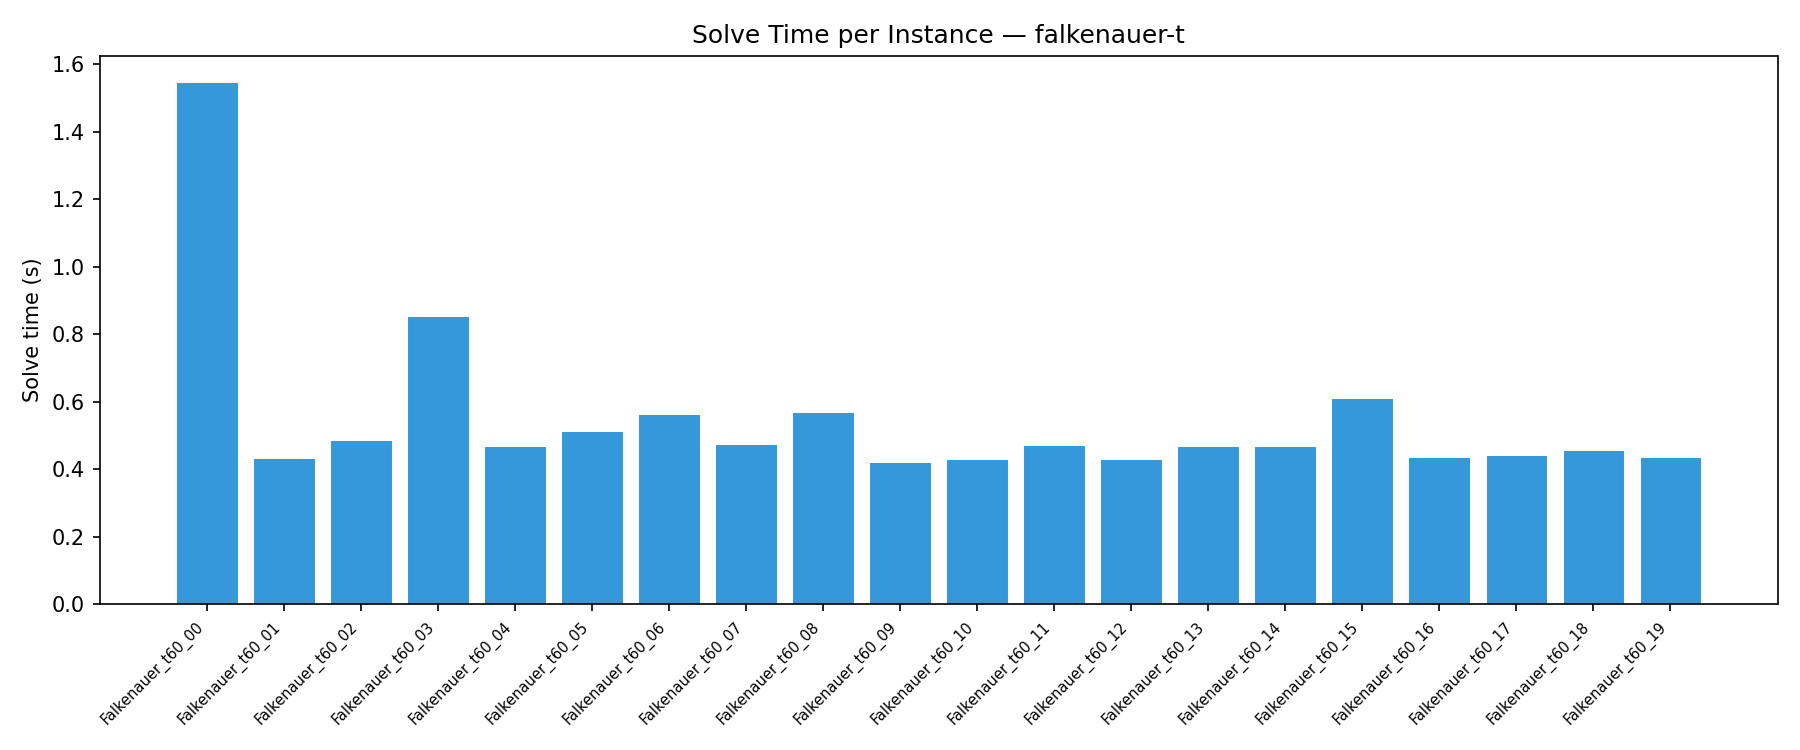


Fig 2 — Bins used vs continuous lower bound


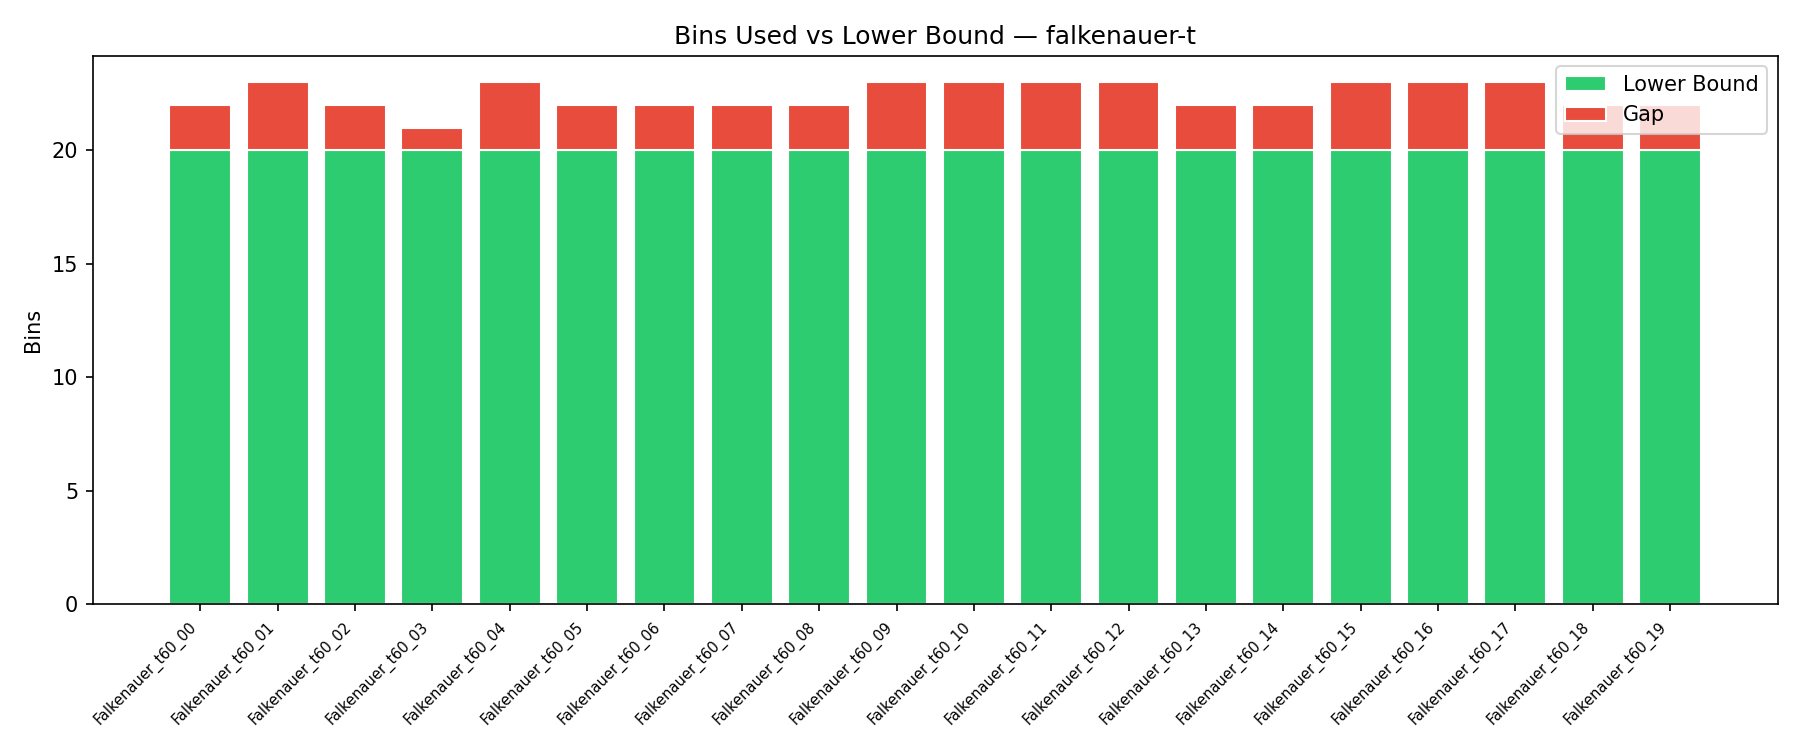

In [ ]:
display_graphs(csv_path)
